<a href="https://colab.research.google.com/github/pratbharat/-advancecfdwithpratyush/blob/main/First_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import pandas as pd

In [3]:
tensor_2d = torch.randn(3,4)
tensor_2d

tensor([[-1.4636,  0.8340, -0.9607, -0.3291],
        [-0.5473, -0.1555, -1.3581,  0.2142],
        [-0.5756,  0.0940,  0.2461,  0.9647]])

In [4]:
tensor_3d = torch.zeros(2,3,4)
tensor_3d

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [5]:
my_torch = torch.arange(10)
my_torch

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [6]:
my_torch.reshape(2,5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [7]:
my_torch.reshape(2,6)

RuntimeError: shape '[2, 6]' is invalid for input of size 10

In [9]:
my_torch.reshape(-1,2)

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])

In [10]:
my_tesnor4 = torch.arange(20)
my_tesnor4

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])

In [12]:
my_tesnor5= my_tesnor4.reshape(5,4)

In [13]:
my_tesnor5

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

In [16]:
my_tesnor5[0,:]

tensor([0, 1, 2, 3])

In [17]:
#Simple Neural Network
import torch
import torch.nn as nn
import torch.nn.functional as F

In [29]:
#Create Neural Network Model
class Net(nn.Module):
   #Input Layer : 4 -> Output Layer -> 3
   #Hidden -> 2 , 8-> 9
    def __init__(self,in_feat= 4, h1=8, h2= 9, out=3):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(in_feat,h1)
        self.fc2 = nn.Linear(h1,h2)
        self.out = nn.Linear(h2,out)

    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [30]:
model = Net()

In [20]:
url = 'https://raw.githubusercontent.com/kcncell/Iris_dataset/refs/heads/main/Irisdataset.csv'
my_df = pd.read_csv(url)
my_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [22]:
my_df['Species'] = my_df['Species'].map({'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2})
#my_df['Species'] = my_df['Species'].replace(to_replace=[0,1,2], value=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
my_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [34]:
my_df = my_df.drop('Id',axis=1)  #Training dat
X = my_df.drop('Species',axis=1).values  #Training dat
y = my_df['Species'].values  #Target Data


In [42]:
X = torch.FloatTensor(X)
y = torch.LongTensor(y)

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [47]:
criteria = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [50]:
epochs = 5000
losses = []
for i in range(epochs):
  y_predict=model.forward(X_train)
  loss = criteria(y_predict,y_train)
  losses.append(loss.detach().numpy())

  if i % 100 == 0:
    print(f'Epoch: {i} Loss: {loss}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 Loss: 0.03569219261407852
Epoch: 100 Loss: 0.035491228103637695
Epoch: 200 Loss: 0.035291433334350586
Epoch: 300 Loss: 0.035095248371362686
Epoch: 400 Loss: 0.03490564972162247
Epoch: 500 Loss: 0.034724604338407516
Epoch: 600 Loss: 0.0345538854598999
Epoch: 700 Loss: 0.034394994378089905
Epoch: 800 Loss: 0.03424857184290886
Epoch: 900 Loss: 0.034115198999643326
Epoch: 1000 Loss: 0.033995144069194794
Epoch: 1100 Loss: 0.03389684855937958
Epoch: 1200 Loss: 0.033822786062955856
Epoch: 1300 Loss: 0.033751480281353
Epoch: 1400 Loss: 0.033712394535541534
Epoch: 1500 Loss: 0.03365746885538101
Epoch: 1600 Loss: 0.03361392766237259
Epoch: 1700 Loss: 0.033578019589185715
Epoch: 1800 Loss: 0.03355890139937401
Epoch: 1900 Loss: 0.033534374088048935
Epoch: 2000 Loss: 0.033514346927404404
Epoch: 2100 Loss: 0.03350134566426277
Epoch: 2200 Loss: 0.03348706662654877
Epoch: 2300 Loss: 0.03347478806972504
Epoch: 2400 Loss: 0.033468011766672134
Epoch: 2500 Loss: 0.033460523933172226
Epoch: 2600 L

In [52]:
y_test_predict=model.forward(X_test)

In [53]:
criteria(y_test_predict,y_test)

tensor(0.0059, grad_fn=<NllLossBackward0>)

Text(0.5, 0, 'Epochs')

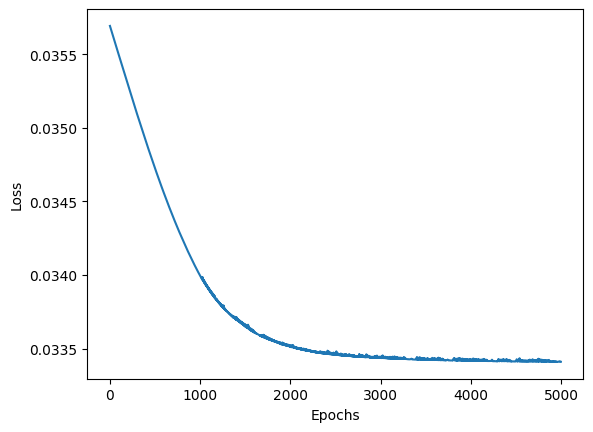

In [51]:
import matplotlib.pyplot as plt
plt.plot(range(epochs),losses)
plt.ylabel('Loss')
plt.xlabel('Epochs')